In [70]:
#Import libraries for the analysis.

import pandas as pd
from pathlib import Path

In [71]:
#Import the file for analysis.

clean_data_path = Path("../Data/cleaned")

list(clean_data_path.glob("*.csv"))

[WindowsPath('../Data/cleaned/electricity_gdp_cleaned.csv')]

In [72]:
clean_data_file = pd.read_csv(
    clean_data_path / "electricity_gdp_cleaned.csv"
)

In [73]:
#Confirm file imported correctly.

display(clean_data_file)

,country_code,country_name,year,electricity_access,gdp_per_capita
0,AFG,Afghanistan,2000,4.4,308.318270
1,AFG,Afghanistan,2001,9.3,277.118051
2,AFG,Afghanistan,2002,14.1,338.139974
3,AFG,Afghanistan,2003,19.0,346.071627
4,AFG,Afghanistan,2004,23.8,338.637274
...,...,...,...,...,...
4909,ZWE,Zimbabwe,2019,46.7,1357.530878
4910,ZWE,Zimbabwe,2020,52.7,1230.819334
4911,ZWE,Zimbabwe,2021,49.0,1312.200014
4912,ZWE,Zimbabwe,2022,50.1,1369.197615


In [74]:
#Technically a requirement, but largely nonsense, especially since it's unevenly representative of countries.

summary_stats = clean_data_file.describe()
print(summary_stats)

              year  electricity_access  gdp_per_capita
count  4914.000000         4914.000000     4914.000000
mean   2011.575906           81.321917    15743.958544
std       6.884677           28.912130    22948.781744
min    2000.000000            1.300000      233.032393
25%    2006.000000           69.925000     1899.520454
50%    2012.000000           99.000000     5689.505326
75%    2018.000000          100.000000    20659.420009
max    2023.000000          100.000000   225884.077199


In [75]:
#Now, by country instead. This is more meaningful, but less accessible.

clean_data_file.drop(columns=["year"]).groupby("country_name").describe()

electricity_access                                \
                                   count        mean        std    min   
country_name                                                             
Afghanistan                         24.0   58.266667  32.648439    4.4   
Albania                             24.0   99.737500   0.269964   99.4   
Algeria                             24.0   99.133333   0.481543   98.6   
Andorra                             24.0  100.000000   0.000000  100.0   
Angola                              24.0   36.904167   8.508281   20.0   
...                                  ...         ...        ...    ...   
Virgin Islands (U.S.)               21.0  100.000000   0.000000  100.0   
West Bank and Gaza                  24.0   99.725000   0.342941   98.8   
Yemen, Rep.                         19.0   59.657895   8.649233   49.2   
Zambia                              24.0   30.375000  10.697836   16.7   
Zimbabwe                            24.0   40.966667   7.302213   32.3   

                                                       gdp_per_capita  \
                           25%     50%      75%    max          count   
country_name                                                            
Afghanistan             32.300   58.15   90.475   97.7           24.0   
Albania                 99.400   99.90  100.000  100.0           24.0   
Algeria                 98.675   99.10   99.500  100.0           24.0   
Andorra                100.000  100.00  100.000  100.0           24.0   
Angola                  30.225   37.40   43.500   51.1           24.0   
...                        ...     ...      ...    ...            ...   
Virgin Islands (U.S.)  100.000  100.00  100.000  100.0           21.0   
West Bank and Gaza      99.675   99.90  100.000  100.0           24.0   
Yemen, Rep.             52.500   58.40   64.050   79.2           19.0   
Zambia                  21.575   28.10   40.225   51.1           24.0   
Zimbabwe                35.475   38.30   44.350   62.0           24.0   

                                                                              \
                               mean          std           min           25%   
country_name                                                                   
Afghanistan              456.053629   102.951490    277.118051    366.728769   
Albania                 3823.870818  1196.432209   1991.914359   2848.987704   
Algeria                 4364.237894   349.186264   3553.324205   4265.612234   
Andorra                38164.633497  2055.616735  34113.817378  36661.893892   
Angola                  3096.951878   504.848039   2172.463267   2778.363521   
...                             ...          ...           ...           ...   
Virgin Islands (U.S.)  40567.101977  5796.006830  34007.352941  35174.101994   
West Bank and Gaza      2878.298359   467.157924   1836.980425   2562.555164   
Yemen, Rep.             1947.049140   420.651130   1079.329384   1965.810273   
Zambia                  1132.597652   190.129236    804.484634    958.692488   
Zimbabwe                1284.257368   223.930281    803.044945   1146.316224   

                                                                 
                                50%           75%           max  
country_name                                                     
Afghanistan              453.238968    559.088543    580.603833  
Albania                 3724.871199   4709.629029   6204.435256  
Algeria                 4456.678575   4640.677483   4768.731401  
Andorra                38369.709516  39848.877748  41322.052921  
Angola                  3176.239142   3531.324082   3746.816200  
...                             ...           ...           ...  
Virgin Islands (U.S.)  37313.048493  46021.590573  50174.752894  
West Bank and Gaza      2962.153980   3246.475731   3483.099035  
Yemen, Rep.             2129.772688   2235.246714   2356.199604  
Zambia                  1218.599623   1298.889142

In [76]:
#Transform the data so we're dealing with by country averages:

bycountry_data_file = clean_data_file.drop(columns=["year","country_code"]).groupby("country_name").mean()
print(bycountry_data_file)

                       electricity_access  gdp_per_capita
country_name                                             
Afghanistan                     58.266667      456.053629
Albania                         99.737500     3823.870818
Algeria                         99.133333     4364.237894
Andorra                        100.000000    38164.633497
Angola                          36.904167     3096.951878
...                                   ...             ...
Virgin Islands (U.S.)          100.000000    40567.101977
West Bank and Gaza              99.725000     2878.298359
Yemen, Rep.                     59.657895     1947.049140
Zambia                          30.375000     1132.597652
Zimbabwe                        40.966667     1284.257368

[211 rows x 2 columns]


In [77]:
#Now, much more meaningful statistics:

bycountry_summary_stats = bycountry_data_file.describe()
print(bycountry_summary_stats)

       electricity_access  gdp_per_capita
count          211.000000      211.000000
mean            81.126672    16655.757583
std             28.138198    24894.544121
min              3.100000      259.562683
25%             66.275000     2018.587274
50%             98.562500     5717.674813
75%            100.000000    21147.796402
max            100.000000   167187.157310


In [78]:
#Here's the correlation calculation:

electric_gdp_corr = bycountry_data_file.corr()
print(electric_gdp_corr)

                    electricity_access  gdp_per_capita
electricity_access            1.000000        0.404047
gdp_per_capita                0.404047        1.000000


<Axes: xlabel='electricity_access', ylabel='gdp_per_capita'>

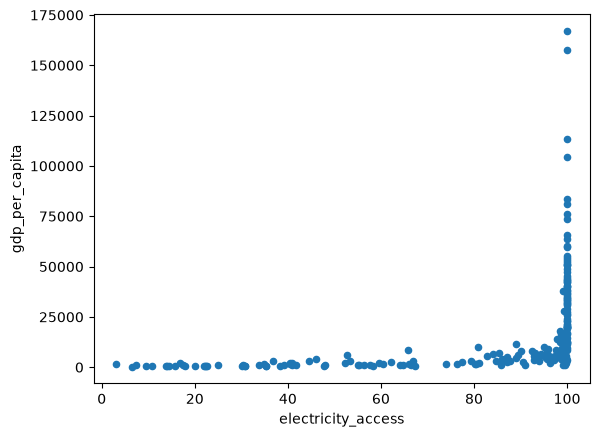

In [79]:
#However, we suspect the relationship is nonlinear, so we graph the two.

bycountry_data_file.plot.scatter(x="electricity_access", y="gdp_per_capita")

In [83]:
#Well that relationship is horrifying. Let's check the actual datafile and make sure it makes sense.
pd.set_option("display.max_rows", None)
print(bycountry_data_file.head(500))

                                electricity_access  gdp_per_capita
country_name                                                      
Afghanistan                              58.266667      456.053629
Albania                                  99.737500     3823.870818
Algeria                                  99.133333     4364.237894
Andorra                                 100.000000    38164.633497
Angola                                   36.904167     3096.951878
Antigua and Barbuda                      98.966667    16903.909425
Argentina                                98.420833    12320.201243
Armenia                                  99.541667     3103.198402
Aruba                                    99.375000    27960.462527
Australia                               100.000000    54508.582967
Austria                                 100.000000    43224.547668
Azerbaijan                               99.700000     4350.953685
Bahamas, The                            100.000000    31423.13